<a href="https://colab.research.google.com/github/soilzx/MedQuAD-RAG/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MedQuAD Data Analysis

This notebook loads, cleans, and examines the MedQuAD dataset for the first project milestone.

# Imports

In [2]:
from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt

#Load the dataset

In [1]:
from datasets import load_dataset

ds = load_dataset("lavita/MedQuAD")

README.md:   0%|          | 0.00/2.77k [00:00<?, ?B/s]

data/train-00000-of-00001-e36383d177026d(…): reconstructing file:   0%|          |  0.00B / 10.7MB            

data/train-00000-of-00001-e36383d177026d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

#Convert it to a DataFrame

In [5]:
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (47441, 13)
Columns: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer']


,document_id,document_source,document_url,category,umls_cui,umls_semantic_types,umls_semantic_group,synonyms,question_id,question_focus,question_type,question,answer
0,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-1,keratoderma with woolly hair,information,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of rel...
1,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-2,keratoderma with woolly hair,frequency,How many people are affected by keratoderma wi...,Keratoderma with woolly hair is rare; its prev...
2,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-3,keratoderma with woolly hair,genetic changes,What are the genetic changes related to kerato...,"Mutations in the JUP, DSP, DSC2, and KANK2 gen..."
3,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-4,keratoderma with woolly hair,inheritance,Is keratoderma with woolly hair inherited ?,Most cases of keratoderma with woolly hair hav...
4,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,None,C0343073,T047,Disorders,KWWH,0000559-5,keratoderma with woolly hair,treatment,What are the treatments for keratoderma with w...,These resources address the diagnosis or manag...


In [16]:
analysis_df = df.dropna(subset=["question", "answer"]).copy()

analysis_df = analysis_df[
    analysis_df["question"].str.strip().ne("")
    & analysis_df["answer"].str.strip().ne("")
]

print("Usable records:", len(analysis_df))

Usable records: 16407


#Representative samples

In [17]:
pd.set_option("display.max_colwidth", 150)

sample_columns = [
    "question",
    "question_type",
    "document_source",
    "answer"

]

samples = analysis_df[sample_columns].sample(
    n=5,
    random_state=42
)

display(samples)

,question,question_type,document_source,answer
3634,What are the treatments for dihydropyrimidinase deficiency ?,treatment,GHR,These resources address the diagnosis or management of dihydropyrimidinase deficiency: - Genetic Testing Registry: Dihydropyrimidinase deficiency...
33249,Who is at risk for Parasites - Cysticercosis? ?,susceptibility,CDC,"Cysticercosis is an infection caused by the larvae of the tapeworm, Taenia solium. A person with an adult tapeworm, which lives in the person’s gu..."
4395,What is (are) phenylketonuria ?,information,GHR,Phenylketonuria (commonly known as PKU) is an inherited disorder that increases the levels of a substance called phenylalanine in the blood. Pheny...
10277,Is Laron syndrome inherited ?,inheritance,GARD,"Is Laron syndrome inherited? Most cases of Laron syndrome are inherited in an autosomal recessive manner. This means that to be affected, a person..."
149,What are the treatments for globozoospermia ?,treatment,GHR,These resources address the diagnosis or management of globozoospermia: - Association for Reproductive Medicine: Semen Analysis - Centers for Di...


#Answer-length distribution

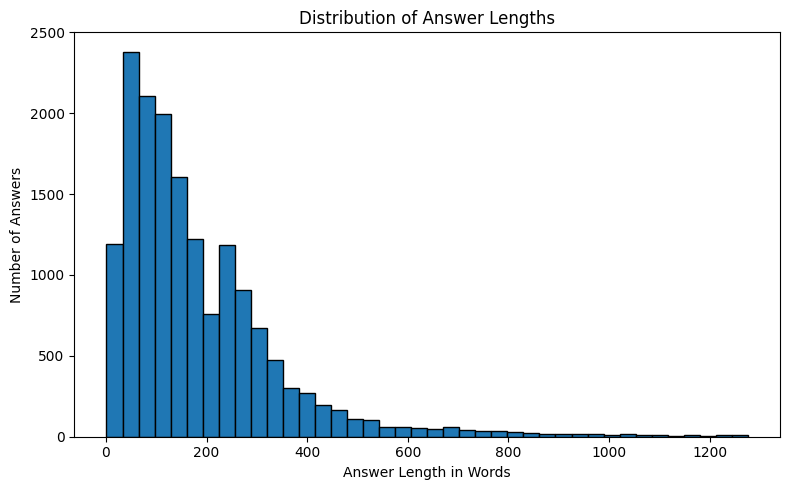

In [18]:
analysis_df["answer_length"] = (
    analysis_df["answer"]
    .str.split()
    .str.len()
)

upper_limit = analysis_df["answer_length"].quantile(0.99)
plot_data = analysis_df[
    analysis_df["answer_length"] <= upper_limit
]

plt.figure(figsize=(8, 5))
plt.hist(
    plot_data["answer_length"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Answer Lengths")
plt.xlabel("Answer Length in Words")
plt.ylabel("Number of Answers")
plt.tight_layout()
plt.show()